# NAICS-2 Classification with RBF SVM

3072-dim embeddings from `text-embedding-3-large`, RBF SVM on PCA-reduced features.

In [1]:
import pandas as pd
import numpy as np
import json
import os
import time
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
csv_path = '../../.ipynb_checkpoints/ExioNAICS_embeddings_large_full.csv'
npy_cache = csv_path.rsplit('.', 1)[0] + '.npy'

df = pd.read_csv(csv_path)
print(f"Shape: {df.shape}")

if os.path.exists(npy_cache):
    print(f"\nLoading cached embeddings from {npy_cache}")
    start = time.time()
    X = np.load(npy_cache)
    print(f"Done in {time.time()-start:.1f}s")
else:
    print("\nParsing embeddings...")
    start = time.time()
    X = np.array([json.loads(e) for e in df['embeddings']], dtype=np.float32)
    print(f"Done in {time.time()-start:.1f}s")
    np.save(npy_cache, X)

df['emb'] = list(X)
print(f"Embedding shape: {X.shape}")

Shape: (20535, 6)

Loading cached embeddings from ../../.ipynb_checkpoints/ExioNAICS_embeddings_large_full.npy
Done in 0.0s
Embedding shape: (20535, 3072)


In [3]:
df = df.drop_duplicates(subset=['Company Name']).reset_index(drop=True)
X = normalize(np.array(df['emb'].tolist()))

NAICS2_MAP = {31: 33, 32: 33, 44: 45, 48: 49}
df['NAICS_2_merged'] = df['NAICS_2 Code'].replace(NAICS2_MAP)

le2 = LabelEncoder()
y2 = le2.fit_transform(df['NAICS_2_merged'].astype(str))

print(f"Total samples: {len(df)}, Classes: {len(le2.classes_)}")

SEED = 192
PCA_DIMS = 323
TEST_SIZE = 0.1
TOP_K = [1, 3, 5]

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y2, test_size=TEST_SIZE, random_state=SEED, stratify=y2
)
print(f"Dev: {len(X_dev)}, Test: {len(X_test)} (held out)")
print(f"PCA to {PCA_DIMS} dims")

Total samples: 14140, Classes: 20
Dev: 12726, Test: 1414 (held out)
PCA to 323 dims


## PCA Elbow

Pick `PCA_DIMS` from the knee of the cumulative variance curve. PCA fit on dev only.

Fitting PCA with 1024 components on dev set...
Done in 1.1s

Elbow at k = 212  (cum var = 0.7243)
Variance thresholds:
   80%: k = 323
   90%: k = 638
   95%: k = 1021
   99%: not reached within 1024 components


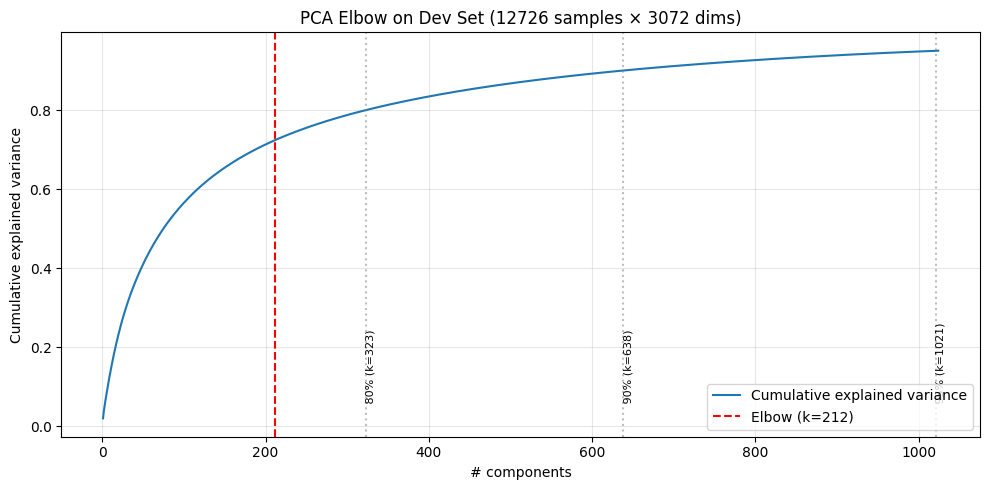

In [4]:
import matplotlib.pyplot as plt

MAX_COMPONENTS = 1024

print(f"Fitting PCA with {MAX_COMPONENTS} components on dev set...")
start = time.time()
pca_probe = PCA(n_components=MAX_COMPONENTS, svd_solver='randomized', random_state=SEED)
pca_probe.fit(X_dev)
print(f"Done in {time.time()-start:.1f}s")

cumvar = np.cumsum(pca_probe.explained_variance_ratio_)
ks = np.arange(1, len(cumvar) + 1)

p1 = np.array([ks[0], cumvar[0]])
p2 = np.array([ks[-1], cumvar[-1]])
chord = p2 - p1
chord_norm = chord / np.linalg.norm(chord)

points = np.column_stack([ks, cumvar])
vec = points - p1
proj_len = vec @ chord_norm
proj_pts = np.outer(proj_len, chord_norm) + p1
distances = np.linalg.norm(points - proj_pts, axis=1)
elbow_k = int(ks[np.argmax(distances)])

thresholds = [0.80, 0.90, 0.95, 0.99]
threshold_ks = {}
for t in thresholds:
    if cumvar[-1] >= t:
        threshold_ks[t] = int(ks[np.argmax(cumvar >= t)])
    else:
        threshold_ks[t] = None

print(f"\nElbow at k = {elbow_k}  (cum var = {cumvar[elbow_k-1]:.4f})")
print(f"Variance thresholds:")
for t, k in threshold_ks.items():
    if k is not None:
        print(f"  {int(t*100):>3}%: k = {k}")
    else:
        print(f"  {int(t*100):>3}%: not reached within {MAX_COMPONENTS} components")

plt.figure(figsize=(10, 5))
plt.plot(ks, cumvar, lw=1.5, label='Cumulative explained variance')
plt.axvline(elbow_k, color='red', linestyle='--', label=f'Elbow (k={elbow_k})')
for t, k in threshold_ks.items():
    if k is not None:
        plt.axvline(k, color='gray', linestyle=':', alpha=0.5)
        plt.text(k, 0.05, f' {int(t*100)}% (k={k})', rotation=90, fontsize=8, va='bottom')
plt.xlabel('# components')
plt.ylabel('Cumulative explained variance')
plt.title(f'PCA Elbow on Dev Set ({X_dev.shape[0]} samples × {X_dev.shape[1]} dims)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Test Evaluation

Training final model on full dev set...
Done in 88.5s
  Test Top-1: 0.6768
  Test Top-3: 0.8967
  Test Top-5: 0.9547


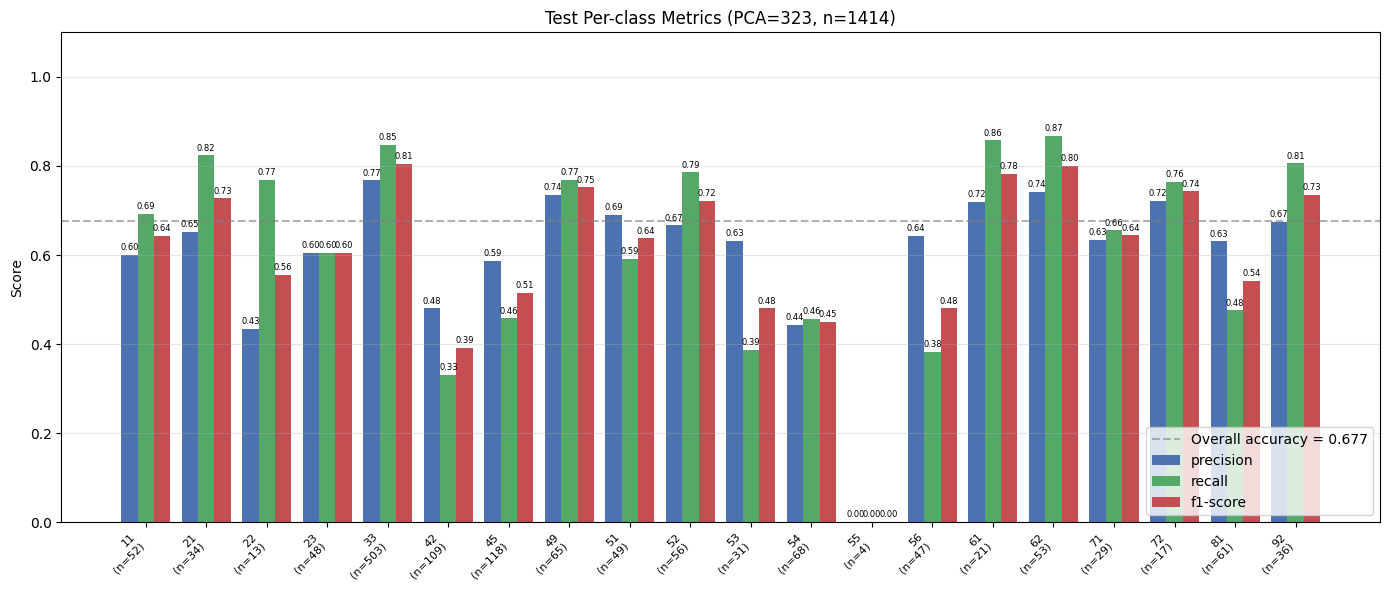

Overall accuracy: 0.6768
Macro avg     : P=0.603  R=0.616  F1=0.600
Weighted avg  : P=0.666  R=0.677  F1=0.665


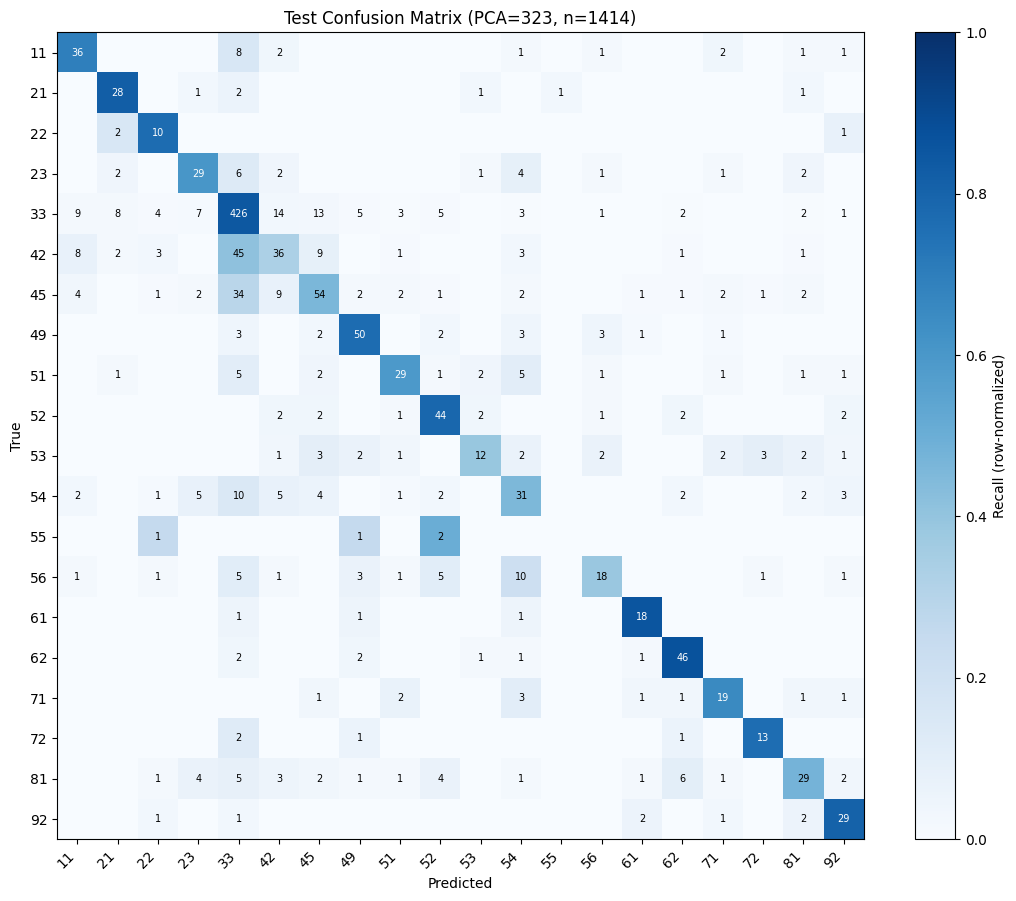

In [5]:
print("Training final model on full dev set...")
start = time.time()

pca_final = PCA(n_components=PCA_DIMS, random_state=SEED)
X_dev_pca = pca_final.fit_transform(X_dev)
X_test_pca = pca_final.transform(X_test)

final_model = SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True, random_state=SEED)
final_model.fit(X_dev_pca, y_dev)
print(f"Done in {time.time()-start:.1f}s")

proba_test = final_model.predict_proba(X_test_pca)
y_test_pred = np.argmax(proba_test, axis=1)

for k in TOP_K:
    top_k_preds = np.argsort(proba_test, axis=1)[:, -k:]
    correct = np.any(top_k_preds == y_test[:, None], axis=1).mean()
    print(f"  Test Top-{k}: {correct:.4f}")


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, where=row_sums > 0, out=np.zeros_like(cm, dtype=float))

    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] == 0:
                continue
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f"{cm[i, j]}", ha='center', va='center',
                    color=color, fontsize=7)

    fig.colorbar(im, ax=ax, label='Recall (row-normalized)')
    plt.tight_layout()
    plt.show()
    return cm


def plot_classification_metrics(y_true, y_pred, class_names, title):
    report = classification_report(
        y_true, y_pred, target_names=list(class_names),
        output_dict=True, zero_division=0
    )
    metrics = ['precision', 'recall', 'f1-score']
    colors = ['#4C72B0', '#55A868', '#C44E52']
    n = len(class_names)
    x = np.arange(n)
    width = 0.27

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, m in enumerate(metrics):
        values = [report[c][m] for c in class_names]
        bars = ax.bar(x + (i - 1) * width, values, width, label=m, color=colors[i])
        ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=2)

    supports = [int(report[c]['support']) for c in class_names]
    tick_labels = [f"{c}\n(n={s})" for c, s in zip(class_names, supports)]

    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.axhline(report['accuracy'], color='gray', linestyle='--', alpha=0.6,
               label=f"Overall accuracy = {report['accuracy']:.3f}")
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Overall accuracy: {report['accuracy']:.4f}")
    print(f"Macro avg     : P={report['macro avg']['precision']:.3f}  "
          f"R={report['macro avg']['recall']:.3f}  "
          f"F1={report['macro avg']['f1-score']:.3f}")
    print(f"Weighted avg  : P={report['weighted avg']['precision']:.3f}  "
          f"R={report['weighted avg']['recall']:.3f}  "
          f"F1={report['weighted avg']['f1-score']:.3f}")
    return report


test_report = plot_classification_metrics(
    y_test, y_test_pred, le2.classes_,
    title=f"Test Per-class Metrics (PCA={PCA_DIMS}, n={len(y_test)})"
)

cm_test = plot_confusion_matrix(
    y_test, y_test_pred, le2.classes_,
    title=f"Test Confusion Matrix (PCA={PCA_DIMS}, n={len(y_test)})"
)

## OOD Evaluation

Scoring on `Kathy/ood_dataset_official.csv` (same embedding model). OOD codes `31`, `44`, `48` map to training codes `33`, `45`, `49`.

Loading OOD dataset from ../../.ipynb_checkpoints/ood_dataset_embeddings_large.csv...
OOD shape: (36380, 6)
Loading cached embeddings from ../../.ipynb_checkpoints/ood_dataset_embeddings_large.npy
Embedding shape: (36380, 3072)

Keeping 36380/36380 rows with known labels

Predicting on 36380 OOD samples...
Done in 44.8s

  OOD Top-1: 0.6213
  OOD Top-3: 0.8061
  OOD Top-5: 0.8820


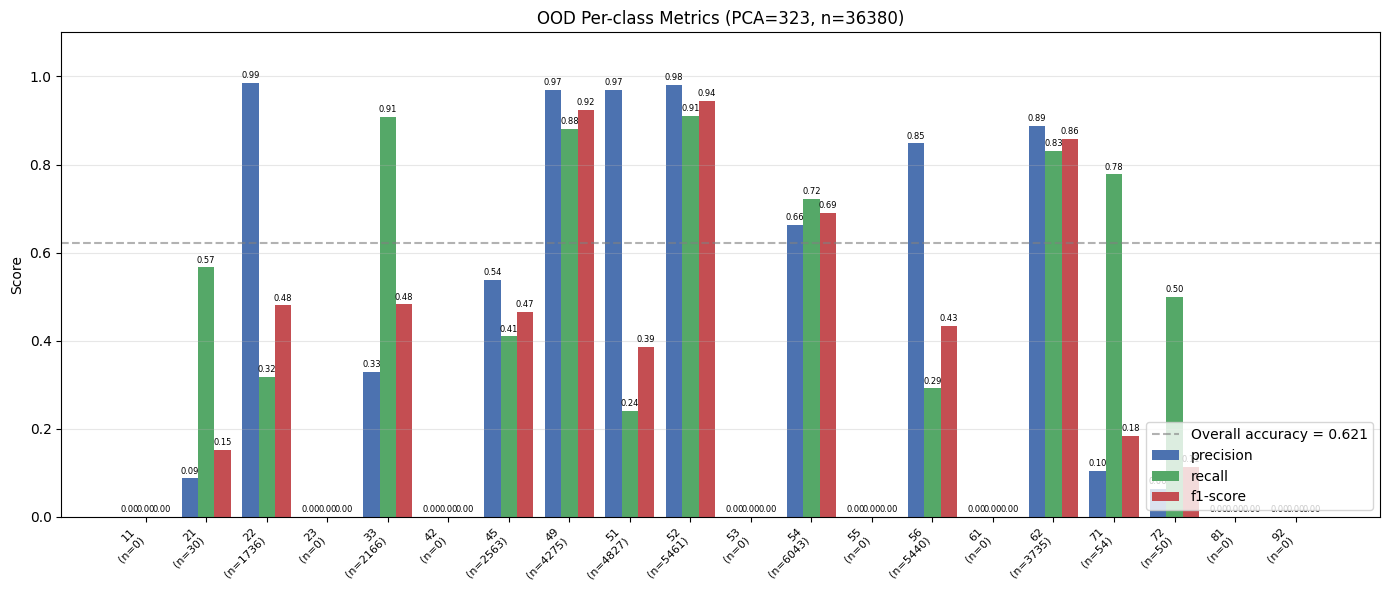

Overall accuracy: 0.6213
Macro avg     : P=0.371  R=0.368  F1=0.306
Weighted avg  : P=0.823  R=0.621  F1=0.654


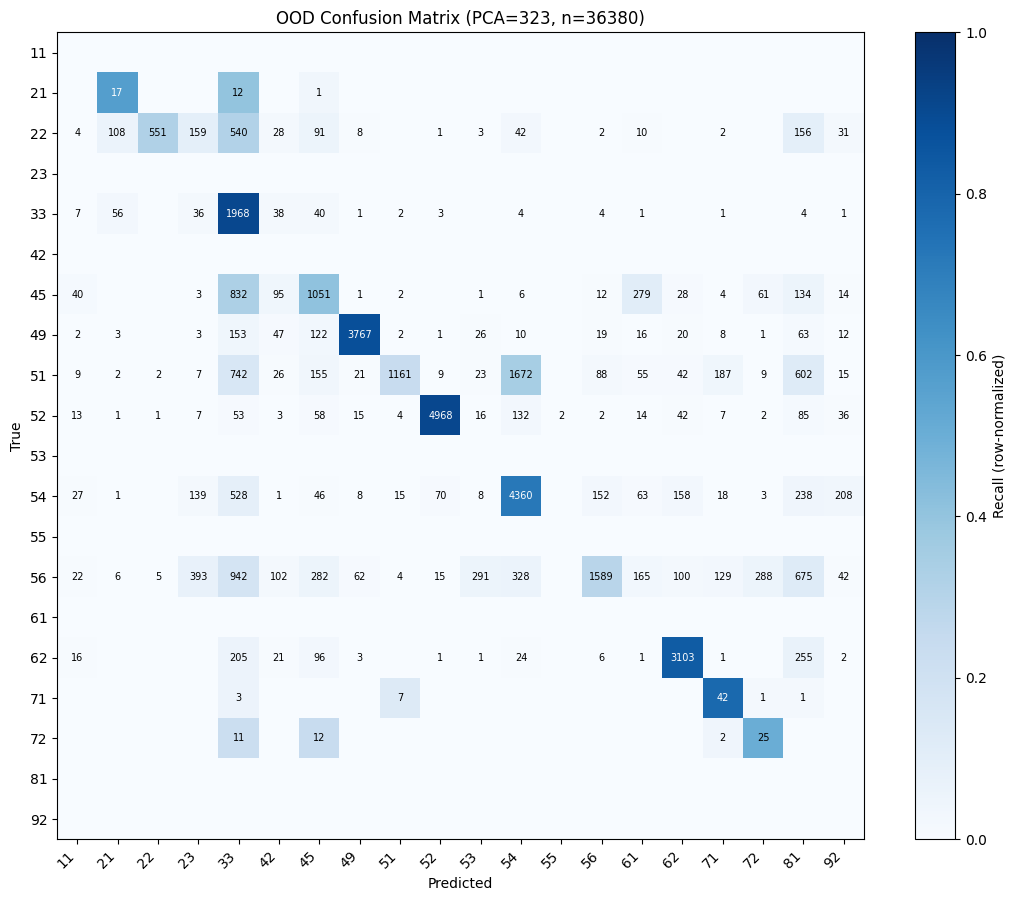

In [6]:
OOD_CSV = '../../.ipynb_checkpoints/ood_dataset_embeddings_large.csv'

print(f"Loading OOD dataset from {OOD_CSV}...")
ood_df = pd.read_csv(OOD_CSV)
print(f"OOD shape: {ood_df.shape}")

ood_npy = OOD_CSV.rsplit('.', 1)[0] + '.npy'
if os.path.exists(ood_npy):
    print(f"Loading cached embeddings from {ood_npy}")
    X_ood = np.load(ood_npy)
else:
    print("Parsing embeddings...")
    start = time.time()
    X_ood = np.array([json.loads(e) for e in ood_df['embeddings']], dtype=np.float32)
    print(f"Done in {time.time()-start:.1f}s")
    np.save(ood_npy, X_ood)
print(f"Embedding shape: {X_ood.shape}")

X_ood = normalize(X_ood)

OOD_TO_TRAIN_MAP = {'31': '33', '44': '45', '48': '49'}
ood_df['naics2_code_str'] = ood_df['naics2_code'].astype(str).replace(OOD_TO_TRAIN_MAP)

known_classes = set(le2.classes_)
mask = ood_df['naics2_code_str'].isin(known_classes)
print(f"\nKeeping {mask.sum()}/{len(mask)} rows with known labels")
dropped = set(ood_df.loc[~mask, 'naics2_code_str'].unique())
if dropped:
    print(f"Dropped labels (not in train classes): {dropped}")

X_ood = X_ood[mask.values]
y_ood = le2.transform(ood_df.loc[mask, 'naics2_code_str'])

X_ood_pca = pca_final.transform(X_ood)

print(f"\nPredicting on {len(y_ood)} OOD samples...")
start = time.time()
proba_ood = final_model.predict_proba(X_ood_pca)
y_ood_pred = np.argmax(proba_ood, axis=1)
print(f"Done in {time.time()-start:.1f}s")

print()
for k in TOP_K:
    top_k_preds = np.argsort(proba_ood, axis=1)[:, -k:]
    correct = np.any(top_k_preds == y_ood[:, None], axis=1).mean()
    print(f"  OOD Top-{k}: {correct:.4f}")

ood_report = plot_classification_metrics(
    y_ood, y_ood_pred, le2.classes_,
    title=f"OOD Per-class Metrics (PCA={PCA_DIMS}, n={len(y_ood)})"
)

cm_ood = plot_confusion_matrix(
    y_ood, y_ood_pred, le2.classes_,
    title=f"OOD Confusion Matrix (PCA={PCA_DIMS}, n={len(y_ood)})"
)